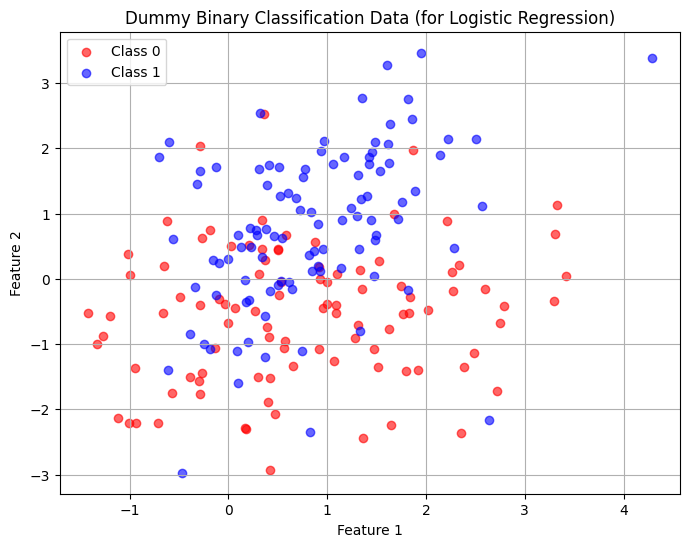

Features shape: (200, 2)
Target shape: (200,)


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.4, random_state=42, stratify=y
)
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [46]:
X_train=pd.DataFrame(X_train)
y_train=pd.DataFrame(y_train)
X_test=pd.DataFrame(X_test)
y_test=pd.DataFrame(y_test)

In [47]:
X_train[1]

0      0.501628
1     -2.921909
2      0.210944
3      0.481159
4     -0.356532
         ...   
115    2.140428
116    0.456330
117    0.061337
118   -0.951342
119   -2.241687
Name: 1, Length: 120, dtype: float64

In [48]:
def information_gain(X_train, y_train, f_name):
    n_decision =  sorted(X_train[f_name].unique())
    total=len(y_train)
    parent_entropy = 0
    left_u = y_train[0].unique()
    H_root = 0
    best_ig=float(-1)
    n_probs = []
    for n_class in left_u:
        p1 =len(y_train[y_train[0]==n_class]) / total
        n_probs.append(p1)
    n_probs=np.array(n_probs)
    H_root= np.sum(-n_probs*np.log2(n_probs))
    H_dn=0
    
    left_x=None
    left_y=None
    right_x=None
    right_y=None
    threshold = None
    
    for th in n_decision[1:-1]:
        left_b_x=X_train[X_train[f_name]<=th]
        left_b_y=y_train[X_train[f_name]<=th]
        right_b_x=X_train[X_train[f_name]>th]
        right_b_y=y_train[X_train[f_name]>th]

        #left
        left_m = len(left_b_y)
        left_u = left_b_y[0].unique()
        n_probs = []
        for n_class in left_u:
            p1 = len(left_b_y[left_b_y[0]==n_class]) / left_m
            n_probs.append(p1)
        
        n_probs = np.array(n_probs)
        H_dn_left = (left_m/total) * np.sum(-n_probs*np.log2(n_probs))        

        #right
        right_m = len(right_b_y)
        right_u = right_b_y[0].unique()
        
        n_probs = []
        for n_class in right_u:
            p1 = len(right_b_y[right_b_y[0]==n_class]) / right_m
            n_probs.append(p1)
        
        n_probs = np.array(n_probs)
        H_dn_right = (right_m/total)* np.sum(-n_probs*np.log2(n_probs))   

        H_dn=H_dn_left+H_dn_right
        
        ig= H_root-H_dn

        if ig>best_ig:
            threshold=th
            best_ig=ig
            left_x=left_b_x
            left_y=left_b_y
            right_x=right_b_x
            right_y=right_b_y
    return best_ig, threshold, [left_x, right_x], [left_y, right_y] 

In [49]:
information_gain(X_train, y_train, 1)

(np.float64(0.16520766441438106),
 np.float64(0.9068843220944874),
 [            0         1
  0    0.027912  0.501628
  1    0.422201 -2.921909
  2    2.337627  0.210944
  3    0.123212  0.481159
  4    0.173727 -0.356532
  ..        ...       ...
  114  0.308913  0.080403
  116  0.335900  0.456330
  117 -0.997938  0.061337
  118  0.569275 -0.951342
  119  1.643461 -2.241687
  
  [90 rows x 2 columns],
              0         1
  6   -0.289521  2.038714
  9    0.777293  1.689448
  18   0.938055  1.960845
  21   0.836045  1.029360
  26   0.415425  1.750820
  33  -0.317460  1.459121
  34   1.753264  1.174897
  35   1.615151  2.057512
  36   0.720172  1.051972
  37  -0.125245  1.709435
  39   0.356129  2.525886
  40   1.873412  1.977956
  43   1.601576  3.270556
  44   1.716336  0.917071
  47  -0.291181  1.652051
  52   1.485197  2.098017
  57   0.323762  2.540229
  62   1.173085  1.858868
  63   1.425791  1.870631
  69   1.306499  0.965736
  71   1.428125  1.757956
  78   1.626101  1.76

In [50]:
number_classes= len(y_train[0].unique())
depth =5

best_x_csvs_branchs, best_y_csvs_branchs = [X_train],[y_train]

tree={}
root_node=[]

for d in range(depth):
    next_x_branches=[]
    next_y_branches=[]
    for best_x_csvs_branch,best_y_csvs_branch in zip(best_x_csvs_branchs,best_y_csvs_branchs):
        IG_value=-np.inf
        best_feature = None
        temp_best_x_csvs_branch = None
        temp_best_y_csvs_branch = None
        decision = None
        y_pred = None
        best_th = None
        for f_name in X_train.columns:
            IG,threshold, x_csvs_branch,y_csvs_branch= information_gain(best_x_csvs_branch,best_y_csvs_branch,f_name)
            if IG>IG_value:
                IG_value=IG
                if IG_value>0:
                    temp_best_x_csvs_branch=x_csvs_branch
                    temp_best_y_csvs_branch = y_csvs_branch
                    best_feature=f_name
                    best_th = threshold
                else:
                    y_pred = best_y_csvs_branch[0].value_counts().idxmax()
        
        print(best_feature,IG_value,threshold)

        node_id=id(best_x_csvs_branch)
        root_node.append(node_id)
        
        tree[node_id] = {            
            "feature": best_feature,
            "ig": IG_value,
            "children": [],
            "pred": y_pred,
            "best_th":best_th
        } 
        
        if temp_best_x_csvs_branch is not None:
            next_x_branches.extend(temp_best_x_csvs_branch)
            next_y_branches.extend(temp_best_y_csvs_branch)

            for child_x in temp_best_x_csvs_branch:
                tree[node_id]["children"].append(id(child_x))   
            
    best_x_csvs_branchs = next_x_branches
    best_y_csvs_branchs = next_y_branches
    if d == depth-1:
        for best_x_csvs_branch, best_y_csvs_branch in zip(best_x_csvs_branchs, best_y_csvs_branchs):
            y_pred = best_y_csvs_branch[0].value_counts().idxmax()
            node_id = id(best_x_csvs_branch)
            tree[node_id] = {            
                "feature": None,
                "ig": None,
                "children": [],
                "pred": y_pred
            }

1 0.16520766441438106 0.9068843220944874
0 0.09099570292543468 -0.27995196917866816
1 0.17523196051238366 1.9608450630045966
0 0.11268364362703709 -0.38161456771853625
None 0.0 -1.3964353765725708
None 0.0 0.9657357103301414
1 0.44643934467101554 2.038714487457047
None 0.0 -2.2116795358514647
1 0.046376469413387134 -0.38161456771853625
None -1.0 None
0 0.2935644431995964 2.140428177066485
0 0.20641062172164726 -0.5721760679097931
0 0.07898214060026854 0.4332505357967865
None -1.0 None
None 0.0 2.0980169346882738


In [51]:
tree,root_node

({2417229001600: {'feature': 1,
   'ig': np.float64(0.16520766441438106),
   'children': [2417290430848, 2417290443280],
   'pred': None,
   'best_th': np.float64(0.9068843220944874)},
  2417290430848: {'feature': 0,
   'ig': np.float64(0.09099570292543468),
   'children': [2417290443616, 2417290441264],
   'pred': None,
   'best_th': np.float64(1.8143881315781485)},
  2417290443280: {'feature': 1,
   'ig': np.float64(0.17523196051238366),
   'children': [2417264880768, 2417264874496],
   'pred': None,
   'best_th': np.float64(1.9608450630045966)},
  2417290443616: {'feature': 0,
   'ig': np.float64(0.11268364362703709),
   'children': [2417264884576, 2417264869456],
   'pred': None,
   'best_th': np.float64(-0.5746856027104121)},
  2417290441264: {'feature': None,
   'ig': np.float64(0.0),
   'children': [],
   'pred': np.int64(0),
   'best_th': None},
  2417264880768: {'feature': None,
   'ig': np.float64(0.0),
   'children': [],
   'pred': np.int64(1),
   'best_th': None},
  2417264

In [52]:
y_pred = []
for i in range(len(X_test)):
    nid = root_node[0]
    while 1:
        search = tree[nid]["feature"]
        if search is not None:
            feature_name = list(X_test.columns).index(search)
            value=X_test.iloc[i,feature_name]
            if value <= tree[nid]["best_th"]:
                children_id=0
            else:
                children_id=1
            nid = tree[nid]["children"][children_id]
        else:
            y_pred.append(tree[nid]["pred"])
            break
y_true_labels = y_test[0].values

accuracy = np.mean(y_true_labels == y_pred) * 100
accuracy

np.float64(81.25)